# Inspect GEOLYTIX Retail Points for UK Car Park Site Selection

**Purpose:** use the GEOLYTIX retail points dataset as a site-discovery source for Phase A of the dissertation.

The aim is not to train on this data. The aim is to identify candidate UK supermarket / retail-park locations that are likely to have visible surface car parks in Digimap aerial imagery.

Target for Phase A: **30 sites**.

Suggested split later:
- **10 UK sites** for optional fine-tuning / calibration
- **20 UK sites** as held-out evaluation/test sites

Keep the split at **site level**, not tile/image level, to avoid leakage.


In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/uk_retail/geolytix/raw/geolytix_retailpoints_v43_202603.csv')

# Fallback path for early exploration if this notebook is run from /mnt/data
if not DATA_PATH.exists():
    DATA_PATH = Path('/mnt/data/geolytix_retailpoints_v43_202603.csv')

assert DATA_PATH.exists(), f'Could not find dataset at {DATA_PATH}'

df = pd.read_csv(DATA_PATH)
df.shape

(19267, 17)

## 1. Inspect columns and basic structure

Expected useful fields:
- `retailer`: parent retailer name
- `fascia`: store format / brand above the door
- `store_name`: individual store name
- `postcode`, `town`, `county`: location descriptors
- `long_wgs`, `lat_wgs`: longitude and latitude for mapping
- `bng_e`, `bng_n`: British National Grid coordinates
- `pqi`: geocoding quality
- `size_band`: store-size category, useful for selecting sites likely to have car parks


In [31]:
df.columns.tolist()

['id',
 'retailer',
 'fascia',
 'store_name',
 'add_one',
 'add_two',
 'town',
 'suburb',
 'postcode',
 'long_wgs',
 'lat_wgs',
 'bng_e',
 'bng_n',
 'pqi',
 'open_date',
 'size_band',
 'county']

In [32]:
df.head(10)

,id,retailer,fascia,store_name,add_one,add_two,town,suburb,postcode,long_wgs,lat_wgs,bng_e,bng_n,pqi,open_date,size_band,county
0,1010025014,Morrisons,Morrisons Daily,Morrisons Daily La Rue De L''Eglise St Peter,La Rue De L''Eglise,NaN,Jersey,NaN,JE3 7AG,-2.184283,49.213016,386579.931951,-76305.306393,Rooftop,20259999.0,"< 3,013 ft2 (280m2)",NaN
1,1010024008,Morrisons,Morrisons Daily,Morrisons Daily Grouville,La Rue a Don,NaN,Jersey,NaN,JE3 9HB,-2.039182,49.189241,397145.275064,-78963.639566,Rooftop,20250408.0,"< 3,013 ft2 (280m2)",NaN
2,1010025026,Morrisons,Morrisons Daily,Morrisons Daily Vingtaine De La Moie,Links Hault,NaN,Jersey,NaN,JE3 8GQ,-2.215415,49.188286,384304.964889,-79048.238688,Rooftop,20249999.0,"< 3,013 ft2 (280m2)",NaN
3,1010018763,Morrisons,Morrisons Daily,Morrisons Daily Grands Vaux,Grand Vaux,NaN,Jersey,NaN,JE2 4NA,-2.096155,49.197940,392995.548761,-77993.009542,Rooftop,20209999.0,"< 3,013 ft2 (280m2)",NaN
4,1010024014,Morrisons,Morrisons Daily,Morrisons Daily Les Quennevais,Les Quennevais Parade,NaN,Jersey,NaN,JE3 8LT,-2.198451,49.193151,385542.420293,-78510.836260,Rooftop,20250399.0,"< 3,013 ft2 (280m2)",NaN
5,1010024012,Morrisons,Morrisons Daily,Morrisons Daily Mulcaster,Mulcaster street,NaN,Jersey,NaN,JE2 3NJ,-2.107039,49.183001,392200.394526,-79652.489236,Rooftop,20250599.0,"< 3,013 ft2 (280m2)",NaN
6,1010024009,Morrisons,Morrisons Daily,Morrisons First Tower,La Route De St Aubin,NaN,Jersey,NaN,JE2 3SH,-2.127326,49.194011,390724.139310,-78426.341840,Rooftop,20259999.0,"< 3,013 ft2 (280m2)",NaN
7,1010024011,Morrisons,Morrisons Daily,Morrisons Daily Parade,4 & 5 The parade,NaN,Jersey,NaN,JE2 3QP,-2.109844,49.186150,391996.456733,-79302.202788,Rooftop,20259999.0,"< 3,013 ft2 (280m2)",NaN
8,1010001437,Marks and Spencer,Marks and Spencer,M&S Guernsey,Creasey and Sons Ltd,St Peter Port,Guernsey,NaN,GY1 2JZ,-2.536054,49.455247,361154.019799,-49256.608944,Rooftop,NaN,"3,013 < 15,069 ft2 (280 < 1,400 m2)",NaN
9,1010013540,Marks and Spencer,Marks and Spencer Foodhall,M&S Guernsey St Llslet Foodhall,Former St Davids Route,Carre St Sampsons L'lslet,Guernsey,NaN,GY2 4RE,-2.545105,49.486445,360523.242731,-45783.725604,Rooftop,20169999.0,"3,013 < 15,069 ft2 (280 < 1,400 m2)",NaN


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19267 entries, 0 to 19266
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          19267 non-null  int64  
 1   retailer    19267 non-null  object 
 2   fascia      19267 non-null  object 
 3   store_name  19267 non-null  object 
 4   add_one     19257 non-null  object 
 5   add_two     4451 non-null   object 
 6   town        19267 non-null  object 
 7   suburb      13794 non-null  object 
 8   postcode    19169 non-null  object 
 9   long_wgs    19267 non-null  float64
 10  lat_wgs     19267 non-null  float64
 11  bng_e       19267 non-null  float64
 12  bng_n       19267 non-null  float64
 13  pqi         19267 non-null  object 
 14  open_date   6773 non-null   float64
 15  size_band   19267 non-null  object 
 16  county      19142 non-null  object 
dtypes: float64(5), int64(1), object(11)
memory usage: 2.5+ MB


## 2. Check missing values and coordinate validity

For site selection, rows without valid latitude/longitude are not useful. Prefer `Rooftop` geocoded stores where possible because they are more likely to point to the store itself rather than only a postcode centroid.


In [34]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary

add_two       14816
open_date     12494
suburb         5473
county          125
postcode         98
add_one          10
town              0
store_name        0
retailer          0
long_wgs          0
lat_wgs           0
bng_e             0
bng_n             0
pqi               0
fascia            0
size_band         0
id                0
dtype: int64

In [35]:
coord_check = df.assign(
    valid_lon=df['long_wgs'].between(-8.5, 2.5),
    valid_lat=df['lat_wgs'].between(49.0, 61.0)
)
coord_check[['valid_lon', 'valid_lat']].value_counts()

valid_lon  valid_lat
True       True         19267
Name: count, dtype: int64

In [36]:
df['pqi'].value_counts(dropna=False)

pqi
Rooftop        19227
Building          24
Third Party       16
Name: count, dtype: int64

## 3. Understand retailer and store-size coverage

For the dissertation, the best starting locations are likely to be larger grocery formats because they are more likely to have visible surface car parks.

Useful retailers/formats are likely to include Aldi, Lidl, Asda Superstore/Supercentre/Supermarket, Tesco/Tesco Extra, Sainsbury's, Morrisons, Waitrose, Marks and Spencer Foodhall, and The Food Warehouse.

Less useful formats are likely to include Express/Local convenience stores, petrol filling station-only records, hospital/rail/travel formats, and city-centre stores with no surface parking.


In [37]:
df['retailer'].value_counts().head(30)

retailer
Tesco                                   2962
The Co-operative Group                  2412
Spar                                    2208
Morrisons                               1844
Sainsburys                              1495
Asda                                    1123
Aldi                                    1082
Lidl                                    1058
Marks and Spencer                       1052
Iceland                                  962
Waitrose                                 430
Budgens                                  416
Farmfoods                                338
Heron                                    317
The Southern Co-operative                251
Central England Co-operative             243
Midcounties Co-operative                 207
Scottish Midland Co-operative            185
East of England Co-operative             121
Cook                                     116
Lincolnshire Co-operative                101
Centra                                   101
H

In [38]:
df['fascia'].value_counts().head(50)

fascia
The Co-operative Food            3605
Tesco Express                    1951
Spar                             1747
Morrisons Daily                  1343
Aldi                             1069
Lidl                             1058
Sainsburys Local                  885
Iceland                           760
Sainsburys                        610
Tesco                             557
Morrisons                         497
Asda Express                      496
Budgens                           416
Spar PFS                          385
Farmfoods                         338
Asda Superstore                   331
Heron                             316
Waitrose                          281
Marks and Spencer BP              279
Tesco Extra                       256
Marks and Spencer                 246
Asda Supermarket                  203
The Food Warehouse                202
Marks and Spencer Simply Food     202
Tesco Express Esso                198
Marks and Spencer Foodhall        128
Cook 

In [39]:
df['size_band'].value_counts(dropna=False)

size_band
< 3,013 ft2 (280m2)                       11967
3,013 < 15,069 ft2 (280 < 1,400 m2)        4494
30,138 ft2 > (2,800 m2)                    1583
15,069 < 30,138 ft2 (1,400 < 2,800 m2)     1223
Name: count, dtype: int64

In [40]:
size_by_retailer = pd.crosstab(df['retailer'], df['size_band'])
size_by_retailer.assign(total=size_by_retailer.sum(axis=1)).sort_values('total', ascending=False).head(25)

size_band,"15,069 < 30,138 ft2 (1,400 < 2,800 m2)","3,013 < 15,069 ft2 (280 < 1,400 m2)","30,138 ft2 > (2,800 m2)","< 3,013 ft2 (280m2)",total
retailer,,,,,
Tesco,273,208,427,2054,2962
The Co-operative Group,16,378,0,2018,2412
Spar,0,0,0,2208,2208
Morrisons,215,40,240,1349,1844
Sainsburys,181,121,335,858,1495
Asda,108,159,342,514,1123
Aldi,40,1041,0,1,1082
Lidl,103,955,0,0,1058
Marks and Spencer,68,360,166,458,1052


## 4. Build a first candidate filter

This filter is deliberately conservative. It tries to keep stores that are likely to have a car park and remove convenience/petrol/travel/hospital formats.

You should still visually inspect every selected site in the map/Digimap before finalising the 30-site sample.


In [41]:
preferred_retailers = [
    'Aldi', 'Lidl', 'Asda', 'Tesco', 'Sainsburys', 'Morrisons',
    'Waitrose', 'Marks and Spencer', 'Iceland'
]

exclude_terms = [
    'Express', 'Local', 'PFS', 'Petrol', 'BP', 'Esso', 'Shell',
    'Hospital', 'Travel', 'MSA', 'Motorway', 'Food To Go', 'Outlet'
]

preferred_size_bands = [
    '15,069 < 30,138 ft2 (1,400 < 2,800 m2)',
    '30,138 ft2 > (2,800 m2)',
    '3,013 < 15,069 ft2 (280 < 1,400 m2)'
]

candidate_df = df.copy()
candidate_df = candidate_df[candidate_df['retailer'].isin(preferred_retailers)]
candidate_df = candidate_df[candidate_df['size_band'].isin(preferred_size_bands)]
candidate_df = candidate_df[candidate_df['long_wgs'].notna() & candidate_df['lat_wgs'].notna()]

exclude_pattern = '|'.join(exclude_terms)
candidate_df = candidate_df[~candidate_df['fascia'].str.contains(exclude_pattern, case=False, na=False)]
candidate_df = candidate_df[~candidate_df['store_name'].str.contains(exclude_pattern, case=False, na=False)]

# Prefer Great Britain mainland for Digimap practicality; remove Channel Islands / Isle of Man unless intentionally needed.
for term in ['Jersey', 'Guernsey', 'Isle of Man']:
    candidate_df = candidate_df[~candidate_df['town'].astype(str).str.contains(term, case=False, na=False)]
    candidate_df = candidate_df[~candidate_df['county'].astype(str).str.contains(term, case=False, na=False)]

candidate_df.shape

(6408, 17)

In [42]:
candidate_df[['retailer','fascia','store_name','town','county','postcode','long_wgs','lat_wgs','pqi','size_band']].head(30)

,retailer,fascia,store_name,town,county,postcode,long_wgs,lat_wgs,pqi,size_band
21,Lidl,Lidl,Lidl Clevedon,Clevedon,Somerset,BS21 6HB,-2.855840,51.435297,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
25,Morrisons,Morrisons,Morrisons Maldon,Maldon,Essex,CM9 6GG,0.664471,51.720282,Rooftop,"15,069 < 30,138 ft2 (1,400 < 2,800 m2)"
46,Aldi,Aldi,Aldi Welshpool,Welshpool,Powys,SY21 7BL,-3.142761,52.659720,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
47,Iceland,Iceland,Iceland Omagh,Omagh,Tyrone,BT78 1ER,-7.303596,54.599459,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
48,Iceland,Iceland,Iceland Bodmin,Bodmin,Cornwall,PL31 2HQ,-4.719368,50.471252,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
49,Aldi,Aldi,Aldi Poole,Poole,Dorset,BH15 1XU,-1.977829,50.715283,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
50,Lidl,Lidl,Lidl Devizes,Devizes,Wiltshire,SN10 2SD,-1.970544,51.364684,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
150,Asda,Asda Superstore,Asda Cookstown Superstore,Cookstown,Tyrone,BT80 8JR,-6.743933,54.632568,Rooftop,"15,069 < 30,138 ft2 (1,400 < 2,800 m2)"
158,Lidl,Lidl,Lidl Halstead,"Halstead, Essex",Essex,CO9 1HJ,0.634482,51.942647,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
176,Asda,Asda Supermarket,Asda Caernarfon Supermarket,Caernarfon,Gwynedd,LL55 1AR,-4.273493,53.143127,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"


In [43]:
candidate_df['retailer'].value_counts()

retailer
Aldi                 1069
Lidl                 1058
Iceland               918
Tesco                 807
Sainsburys            610
Asda                  609
Marks and Spencer     551
Morrisons             495
Waitrose              291
Name: count, dtype: int64

In [44]:
candidate_df['size_band'].value_counts()

size_band
3,013 < 15,069 ft2 (280 < 1,400 m2)       3722
30,138 ft2 > (2,800 m2)                   1522
15,069 < 30,138 ft2 (1,400 < 2,800 m2)    1164
Name: count, dtype: int64

## 5. Optional: focus on practical regions

For Phase A, you do not need a perfectly random UK sample. A defensible purposive sample is acceptable if you explain the criteria:

- visible surface car park
- variety of retailer brands
- variety of urban/suburban/retail-park contexts
- image availability in Digimap
- no site overlap between fine-tuning and test subsets

You may prefer locations near Brighton/London/Bristol/Cardiff/Manchester/Birmingham because they are easier to inspect manually.


In [45]:
focus_terms = [
    'Greater London',
    'Essex',
    'Kent',
    'Surrey',
    'West Sussex',
    'East Sussex',
    'Gloucestershire',
    'Bristol',
    'West Midlands',
    'Cardiff',

    # New areas
    'Hampshire',
    'Berkshire',
    'Buckinghamshire',
    'Oxfordshire',
    'Wiltshire',
    'Dorset',
    'Somerset',
    'Cambridgeshire',
    'Hertfordshire',
    'Bedfordshire'
]

focus_pattern = '|'.join(focus_terms)
focus_df = candidate_df[
    candidate_df['town'].astype(str).str.contains(focus_pattern, case=False, na=False) |
    candidate_df['county'].astype(str).str.contains(focus_pattern, case=False, na=False)
].copy()

focus_df.shape

(2580, 17)

In [46]:
focus_df[['retailer','fascia','store_name','town','county','postcode','long_wgs','lat_wgs','pqi','size_band']].head(50)

,retailer,fascia,store_name,town,county,postcode,long_wgs,lat_wgs,pqi,size_band
21,Lidl,Lidl,Lidl Clevedon,Clevedon,Somerset,BS21 6HB,-2.855840,51.435297,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
25,Morrisons,Morrisons,Morrisons Maldon,Maldon,Essex,CM9 6GG,0.664471,51.720282,Rooftop,"15,069 < 30,138 ft2 (1,400 < 2,800 m2)"
49,Aldi,Aldi,Aldi Poole,Poole,Dorset,BH15 1XU,-1.977829,50.715283,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
50,Lidl,Lidl,Lidl Devizes,Devizes,Wiltshire,SN10 2SD,-1.970544,51.364684,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
158,Lidl,Lidl,Lidl Halstead,"Halstead, Essex",Essex,CO9 1HJ,0.634482,51.942647,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
195,Asda,Asda Supercentre,Asda Patchway Supercentre,Bristol,Gloucestershire,BS34 5TL,-2.597130,51.530591,Rooftop,"30,138 ft2 > (2,800 m2)"
197,Aldi,Aldi,Aldi Fishponds Bristol,Bristol,Bristol City of,BS16 3HJ,-2.533752,51.478151,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
198,Lidl,Lidl,Lidl Mangotsfield Bristol,Bristol,Gloucestershire,BS16 7AE,-2.474715,51.493769,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
201,Lidl,Lidl,Lidl Bristol Berwick Green,Bristol,Gloucestershire,BS10 7TA,-2.622410,51.516349,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"
203,Aldi,Aldi,Aldi Southmead Bristol,Bristol,Bristol City of,BS10 6AS,-2.603358,51.503255,Rooftop,"3,013 < 15,069 ft2 (280 < 1,400 m2)"


## 6. Plot candidates quickly with Matplotlib

This is not a web map, but it is enough to see geographic spread. For interactive inspection, use the map-viewer Toby mentioned or the optional Folium section below.


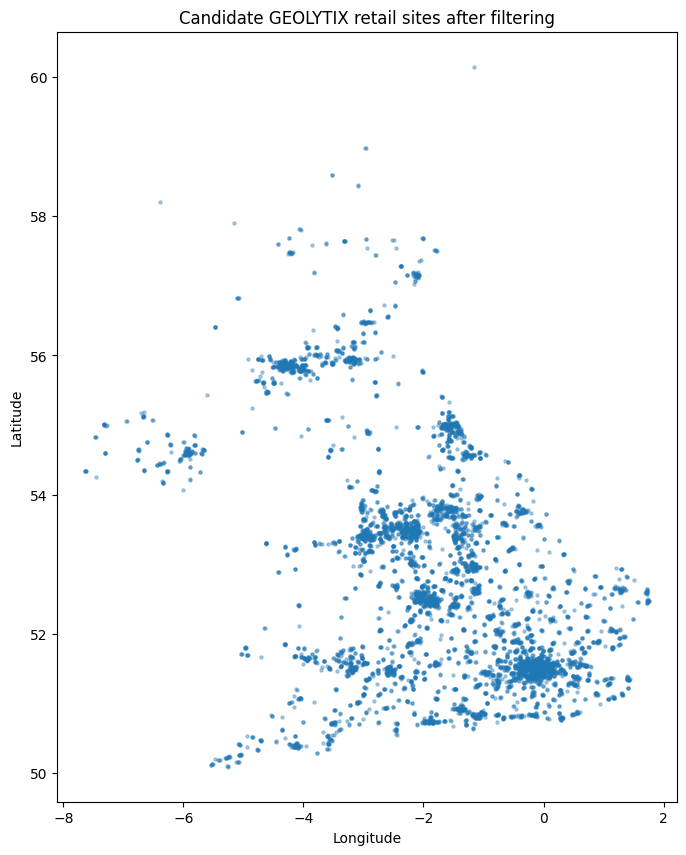

In [47]:
plt.figure(figsize=(8, 10))
plt.scatter(candidate_df['long_wgs'], candidate_df['lat_wgs'], s=5, alpha=0.35)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Candidate GEOLYTIX retail sites after filtering')
plt.show()

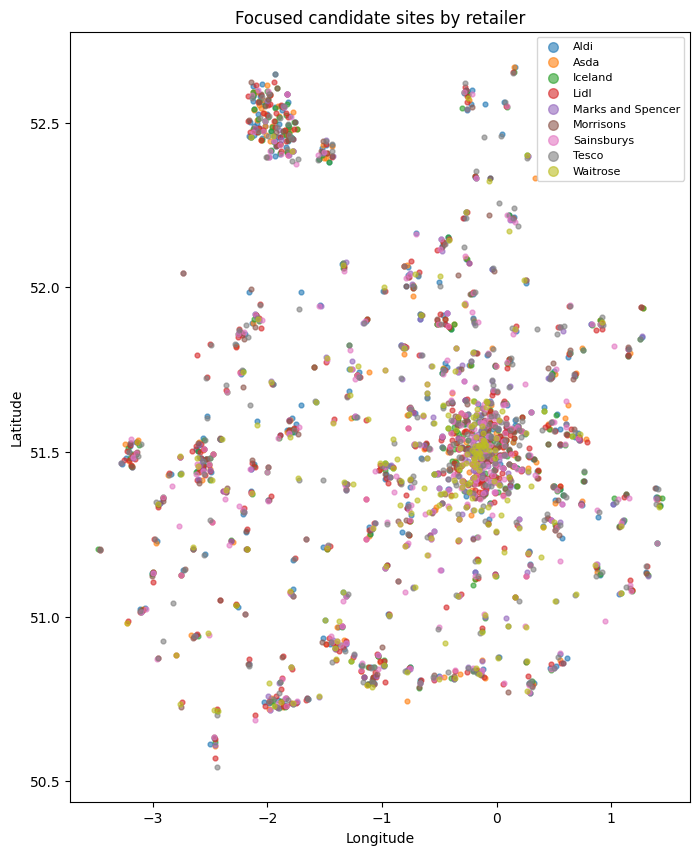

In [48]:
plt.figure(figsize=(8, 10))
for retailer, group in focus_df.groupby('retailer'):
    plt.scatter(group['long_wgs'], group['lat_wgs'], s=12, alpha=0.6, label=retailer)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Focused candidate sites by retailer')
plt.legend(markerscale=2, fontsize=8)
plt.show()

## 7. Optional interactive map

Run this section if `folium` is installed. It creates an HTML map with popup labels for the focused candidates.


In [53]:
try:
    import folium
    from folium.plugins import MarkerCluster

    centre = [focus_df['lat_wgs'].mean(), focus_df['long_wgs'].mean()]
    m = folium.Map(location=centre, zoom_start=7, tiles='OpenStreetMap')
    cluster = MarkerCluster().add_to(m)

    for _, row in focus_df.iterrows():
        popup = f'''
        <b>{row['store_name']}</b><br>
        Retailer: {row['retailer']}<br>
        Fascia: {row['fascia']}<br>
        Town: {row['town']}<br>
        County: {row['county']}<br>
        Postcode: {row['postcode']}<br>
        Size: {row['size_band']}<br>
        PQI: {row['pqi']}
        '''
        folium.Marker(
            [row['lat_wgs'], row['long_wgs']],
            popup=folium.Popup(popup, max_width=300),
            tooltip=row['store_name']
        ).add_to(cluster)

    out_map = Path('geolytix_focused_candidate_map.html')
    m.save(out_map)
    print(f'Saved map to {out_map.resolve()}')
except ImportError:
    print('folium is not installed. You can install it with: pip install folium')

Saved map to /Users/apple/Documents/carpark-project/notebooks/geolytix_focused_candidate_map.html


## 8. Create a 30-site working shortlist

This is not the final sample. It is a working shortlist to inspect in Digimap.

A good 30-site sample should include:
- multiple retailers, not only one chain
- mostly medium/large stores
- surface car parks visible in Digimap
- no duplicate stores from the same retail park unless justified
- a mix of dense urban, suburban, and out-of-town retail-park settings

Suggested final split:
- `uk_train_calibration`: 10 sites
- `uk_test`: 20 sites

Do **not** split tiles from the same site across train and test.


In [57]:
# Remove sites already inspected in UK001–UK031
already_inspected_postcodes = [
    'BS10 7EN', 'RH10 9BN', 'RH12 1AJ', 'RM7 0AN', 'TN24 0SE',
    'CV6 3EX', 'CO12 3HJ', 'CT11 9TT', 'B33 9AN', 'TW4 7DN',
    'BN12 4AL', 'GL52 8NF', 'CF23 9AN', 'RH13 5PX', 'E6 1NN',
    'TW9 4AD', 'ME20 6PW', 'SE28 8RD', 'DA16 1QL', 'HA1 4HX',
    'CO3 8AA', 'KT1 1BU', 'E4 8HP', 'IG10 4PE', 'CR3 5QX',
    'IG8 8GE', 'IG11 7BS', 'CO4 3BQ', 'BN27 1BE', 'KT3 4HE',
    'BS6 7XW'
]

next_candidates = focus_df.copy()
next_candidates = next_candidates[
    ~next_candidates['postcode'].astype(str).str.upper().isin(already_inspected_postcodes)
].copy()

# Prioritise formats most likely to have visible surface car parks
strong_format_terms = [
    'Superstore', 'Supercentre', 'Extra', 'Food Warehouse', 'Retail Park'
]

strong_pattern = '|'.join(strong_format_terms)

next_candidates['format_score'] = 0
next_candidates.loc[
    next_candidates['fascia'].str.contains(strong_pattern, case=False, na=False) |
    next_candidates['store_name'].str.contains(strong_pattern, case=False, na=False) |
    next_candidates['add_one'].astype(str).str.contains(strong_pattern, case=False, na=False),
    'format_score'
] = 2

# Prioritise larger stores
size_score_map = {
    '30,138 ft2 > (2,800 m2)': 3,
    '15,069 < 30,138 ft2 (1,400 < 2,800 m2)': 2,
    '3,013 < 15,069 ft2 (280 < 1,400 m2)': 1
}

next_candidates['size_score'] = next_candidates['size_band'].map(size_score_map).fillna(0)

# Retailers/formats that often have usable surface car parks
retailer_score_map = {
    'Asda': 3,
    'Tesco': 3,
    'Sainsburys': 3,
    'Morrisons': 3,
    'Aldi': 2,
    'Lidl': 2,
    'Iceland': 2,
    'Waitrose': 2,
    'Marks and Spencer': 1
}

next_candidates['retailer_score'] = next_candidates['retailer'].map(retailer_score_map).fillna(0)

next_candidates['candidate_score'] = (
    next_candidates['format_score'] +
    next_candidates['size_score'] +
    next_candidates['retailer_score']
)

max_per_retailer = 4

shortlist = (
    next_candidates
    .sort_values(
        ['candidate_score', 'size_score', 'retailer', 'town'],
        ascending=[False, False, True, True]
    )
    .groupby('retailer', group_keys=False)
    .head(max_per_retailer)
    .sort_values(['candidate_score', 'size_score'], ascending=[False, False])
    .head(30)
)

shortlist = shortlist[
    [
        'id', 'retailer', 'fascia', 'store_name', 'add_one',
        'town', 'county', 'postcode', 'long_wgs', 'lat_wgs',
        'pqi', 'size_band', 'candidate_score'
    ]
].copy()

shortlist['site_id'] = [f'UK{str(i).zfill(3)}' for i in range(32, 32 + len(shortlist))]
shortlist['digimap_checked'] = False
shortlist['accepted'] = ''
shortlist['surface_car_park_visible'] = ''
shortlist['capacity_estimable'] = ''
shortlist['exclude_reason'] = ''
shortlist['proposed_split'] = ''

shortlist

,id,retailer,fascia,store_name,add_one,town,county,postcode,long_wgs,lat_wgs,pqi,size_band,candidate_score,site_id,digimap_checked,accepted,surface_car_park_visible,capacity_estimable,exclude_reason,proposed_split
10182,1010000808,Asda,Asda Superstore,Asda Andover Superstore,Anton Mill Road,Andover,Hampshire,SP10 2RW,-1.482304,51.203758,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK032,False,,,,,
7744,1010000907,Asda,Asda Supercentre,Asda Burgh Heath Supercentre,Reigate Road,Banstead,Surrey,KT20 5NZ,-0.221962,51.308838,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK033,False,,,,,
728,1010000927,Asda,Asda Supercentre,Asda Eastgate Supercentre,Eastgate Shopping Centre,Basildon,Essex,SS14 1AE,0.463380,51.569605,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK034,False,,,,,
10272,1010000812,Asda,Asda Superstore,Asda Basildon Superstore,Heron Retail Park,Basildon,Essex,SS14 3AF,0.443104,51.583281,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK035,False,,,,,
5501,1010003256,Sainsburys,Sainsburys,Sainsburys East Mayne,Cricketers Retail Park,Basildon,Essex,SS13 1SA,0.500383,51.590586,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK036,False,,,,,
14651,1010002781,Sainsburys,Sainsburys,Sainsburys Castle Vale,Castle Vale Retail Park,Birmingham,West Midlands,B35 6HB,-1.796356,52.517690,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK037,False,,,,,
3242,1010002972,Sainsburys,Sainsburys,Sainsburys Tewkesbury Rd,Gallagher Retail Park,Cheltenham,Gloucestershire,GL51 9RR,-2.106618,51.918060,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK038,False,,,,,
10976,1010025373,Sainsburys,Sainsburys,Sainsburys Fareham,Collingwood Retail Park,Fareham,Hampshire,PO14 1AN,-1.185328,50.837654,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK039,False,,,,,
2893,1010006263,Tesco,Tesco Extra,Tesco Abingdon Extra,Marcham Road,Abingdon,Oxfordshire,OX14 1TU,-1.309456,51.667029,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK040,False,,,,,
2671,1010006215,Tesco,Tesco Extra,Tesco Addlestone Extra,117 Station Road,Addlestone,Surrey,KT15 2AS,-0.487354,51.372308,Rooftop,"30,138 ft2 > (2,800 m2)",8,UK041,False,,,,,


In [56]:
shortlist_path = Path('uk_retail_next_candidates_balanced_UK032_UK061.csv')
shortlist.to_csv(shortlist_path, index=False)
shortlist_path.resolve()

PosixPath('/Users/apple/Documents/carpark-project/notebooks/uk_retail_next_candidates_balanced_UK032_UK061.csv')

## 9. Manual Digimap inspection checklist

For each shortlisted site, inspect the aerial imagery and fill in the CSV columns.

Keep the site if:
- the car park is open-air and visible
- cars are visible clearly enough to annotate
- the car park boundary is reasonably clear
- the image resolution is close to 25 cm/pixel
- the imagery capture date can be recorded

Exclude the site if:
- parking is underground or multi-storey
- the store is city-centre with no usable car park
- trees/shadows obscure too many cars
- the car park is shared in a way that cannot be separated or justified
- the imagery is too old/unclear/cloudy

For the final dissertation, record:
- site ID
- retailer/fascia/store name
- postcode
- latitude/longitude
- Digimap imagery capture date
- number of annotated vehicles
- manually counted parking capacity, if occupancy is estimated
- split assignment


## 10. Next notebook after this

Once the 30 sites are confirmed, the next notebook/script should handle:

1. Loading exported Digimap images
2. Cropping/tiling car park areas
3. Running the combined YOLO model for assisted annotation
4. Exporting YOLO-format labels
5. Creating a site-level metadata CSV

The key output of Phase A is a labelled UK dataset, not just the GEOLYTIX shortlist.
